# BASE Test

## Setup Materials

In [1]:
import pylab as plt
import numpy as np
from paarti.utils import maos_utils
from paarti import psfs, psf_plots

#psf_x = [0, 5, 10, 15, 20, 25, 30, 35]  # arcsec
#psf_y = [0, 0,  0,  0,  0,  0,  0,  0,  0,  0]  # arcsec
#psf_wvl = [432, 544, 652, 810, 877, 1020, 1248, 1673, 2200]

directory = 'A_keck_scao_lgs_v20260119/'
seed = 1

%matplotlib inline

# Strehl vs. Radius

In [2]:
maos_utils.print_wfe_metrics(directory=directory, seed=seed)

Looking in directory: A_keck_scao_lgs_v20260119/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1631.9        968.6       1313.4
Closed           338.1        303.4        149.1

Pos  0 
-------  
Open            1631.9        968.6       1313.4
Closed           338.1        303.4        149.1


(array([1631.94395158, 1313.42486718,  968.58462686]),
 array([338.0531461 , 149.05742328, 303.41689827]),
 array([[1631.94395158, 1313.42486718,  968.58462686]]),
 array([[338.0531461 , 149.05742328, 303.41689827]]))

In [3]:
maos_utils.print_psf_metrics_x0y0(directory=directory, oversamp=3, seed=seed)

Looking in A_keck_scao_lgs_v20260119/ for simulation results...
Wavelength Strehl  FWHM_gaus   FWHM_emp r_EE80
(microns)              (mas)      (mas)  (mas)
     0.800   0.01       37.2      100.1  140.8
     1.000   0.03       32.1       68.1  163.4
     1.250   0.10       33.2       44.1  180.7
     1.650   0.24       38.4       44.7  191.9
     2.120   0.41       44.5       51.7  186.6


(array([0.8 , 1.  , 1.25, 1.65, 2.12]),
 array([0.00883863, 0.03381408, 0.0982482 , 0.24455008, 0.41416841]),
 array([37.21047085, 32.11573615, 33.17541493, 38.37339056, 44.48162258]),
 array([100.06500119,  68.12499507,  44.11635864,  44.67902637,
         51.74148849]),
 array([140.81013333, 163.44033333, 180.72786667, 191.8857    ,
        186.57333333]))

In [4]:
mets = maos_utils.get_psf_metrics_over_field(directory, seed=seed)
x, y, w, strehl, fwhm_g, fwhm_e, r_ee50, r_ee80 = mets

Looking in A_keck_scao_lgs_v20260119/ for simulation results...
xx =  0 yy =  0


In [17]:
x.shape

(10, 9)

Text(31, 0.2, 'LGS radius')

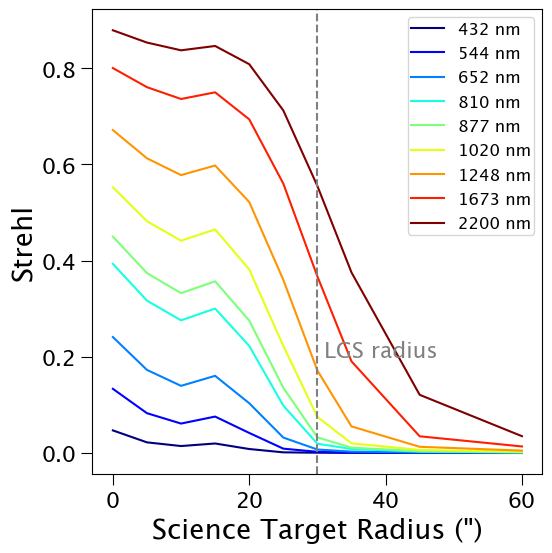

In [18]:
n_wvl = x.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.plot(x[:, ww], strehl[:, ww], color=colors[ww], label=label)    

plt.legend(fontsize=12)
plt.xlabel('Science Target Radius (")')
plt.ylabel('Strehl')
plt.axvline(30, linestyle='--', color='grey')
plt.text(31, 0.2, 'LGS radius', color='grey')

Text(31, 0.2, 'LGS radius')

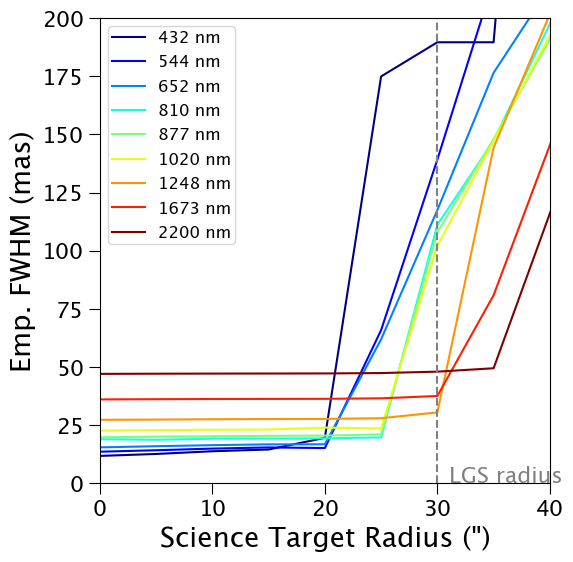

In [19]:
n_wvl = x.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.plot(x[:, ww], fwhm_e[:, ww], color=colors[ww], label=label)    

plt.legend(fontsize=12)
plt.xlabel('Science Target Radius (")')
plt.ylabel('Emp. FWHM (mas)')
plt.axvline(30, linestyle='--', color='grey')
plt.xlim(0, 40)
plt.ylim(0, 200)
plt.text(31, 0.2, 'LGS radius', color='grey')

Text(29, 20, 'LGS radius')

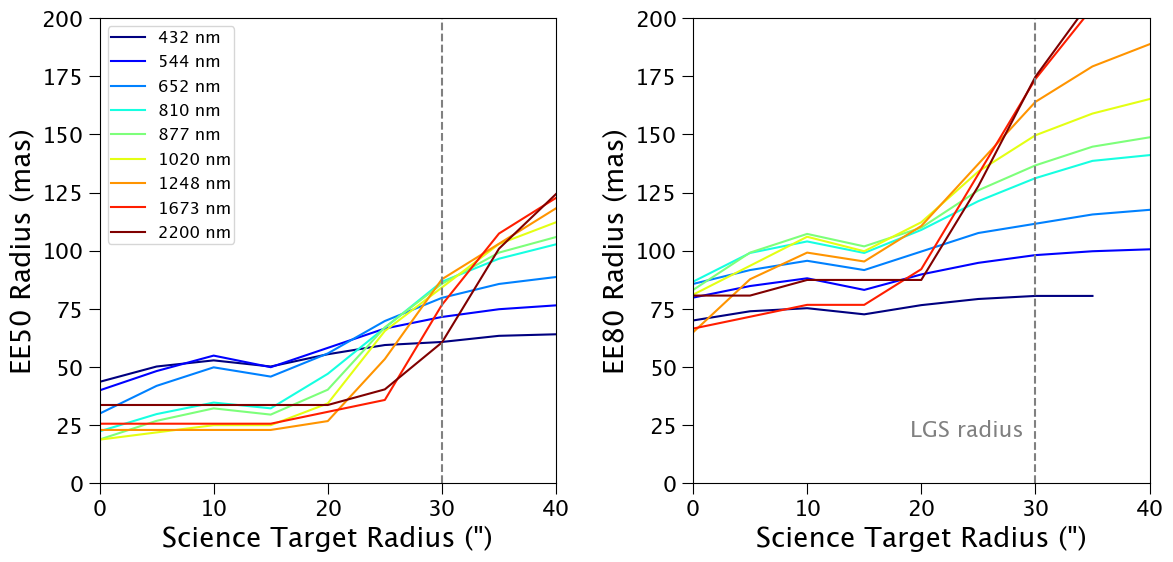

In [29]:
n_wvl = x.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
    
for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    axs[0].plot(x[:, ww], r_ee50[:, ww], color=colors[ww], label=label)    
    axs[1].plot(x[:, ww], r_ee80[:, ww], color=colors[ww])    

axs[0].legend(fontsize=12)
axs[0].set_xlabel('Science Target Radius (")')
axs[1].set_xlabel('Science Target Radius (")')
axs[0].set_ylabel('EE50 Radius (mas)')
axs[1].set_ylabel('EE80 Radius (mas)')
axs[0].axvline(30, linestyle='--', color='grey')
axs[1].axvline(30, linestyle='--', color='grey')
axs[0].set_xlim(0, 40)
axs[0].set_ylim(0, 200)
axs[1].set_xlim(0, 40)
axs[1].set_ylim(0, 200)
axs[1].text(29, 20, 'LGS radius', color='grey', ha='right')

## Display PSFs.

800 nm PSFs vs. distance. 

In [5]:
# Pulled straight from maos_done.conf
nwfs = maos_utils.get_parameter_from_done_conf(directory, "powfs.nwfs")
wfs_x = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetax")
wfs_y = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetay")
wvl = maos_utils.get_parameter_from_done_conf(directory, "evl.wvl")

print(nwfs)
lgs_wfs_x = wfs_x[0:nwfs[0]]
lgs_wfs_y = wfs_y[0:nwfs[0]]

ngs_wfs_x = wfs_x[nwfs[0]:nwfs[0]+nwfs[1]]
ngs_wfs_y = wfs_y[nwfs[0]:nwfs[0]+nwfs[1]]

LGSpos = np.vstack([lgs_wfs_x, lgs_wfs_y]).T
NGSpos = np.vstack([ngs_wfs_x, ngs_wfs_y]).T

# Display 650 nm PSFs
psf_stack = psfs.MAOS_PSF_stack(directory=directory, seed=seed, bandpass=2,
                               LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack.calc_metrics(parallel=True, cut_radius=30)

[6 3 1]
calc_stats in parallel with 6 cores.


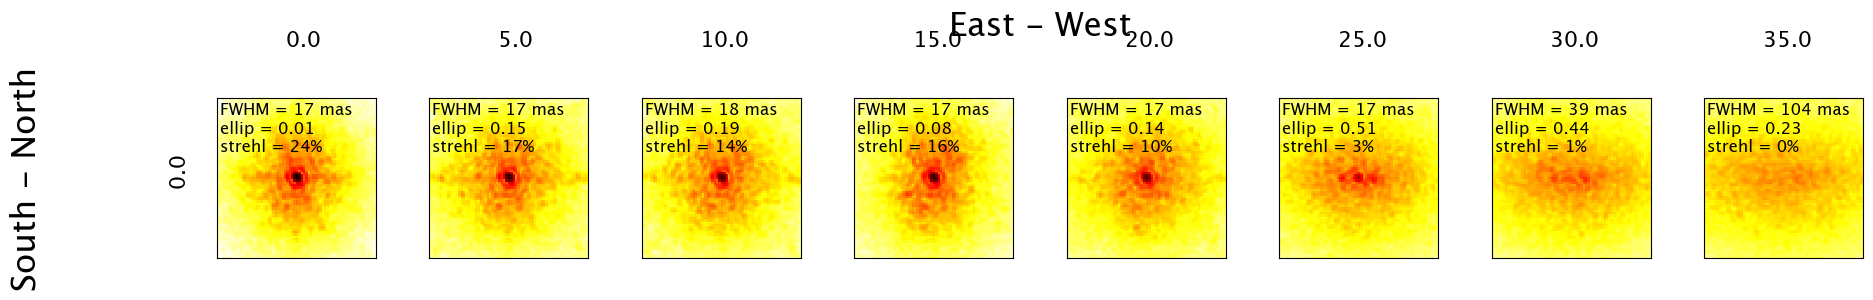

In [248]:
import copy
psf_stack_35 = copy.deepcopy(psf_stack)

idx = np.where(psf_stack_35.pos[:, 0] <= 35)[0]
psf_stack_35.psfs = psf_stack_35.psfs[idx]
psf_stack_35.pos = psf_stack_35.pos[idx]


psf_plots.plot_psf_stack(psf_stack_35, zoom=0.2, box_scale=5, figsize_max=20)

In [245]:
psf_stack_all_wvl = psfs.MAOS_PSF_all_bands_stack(directory=directory, seed=seed, 
                                                  LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack_all_wvl.calc_metrics(parallel=True)

calc_stats in parallel with 6 cores.


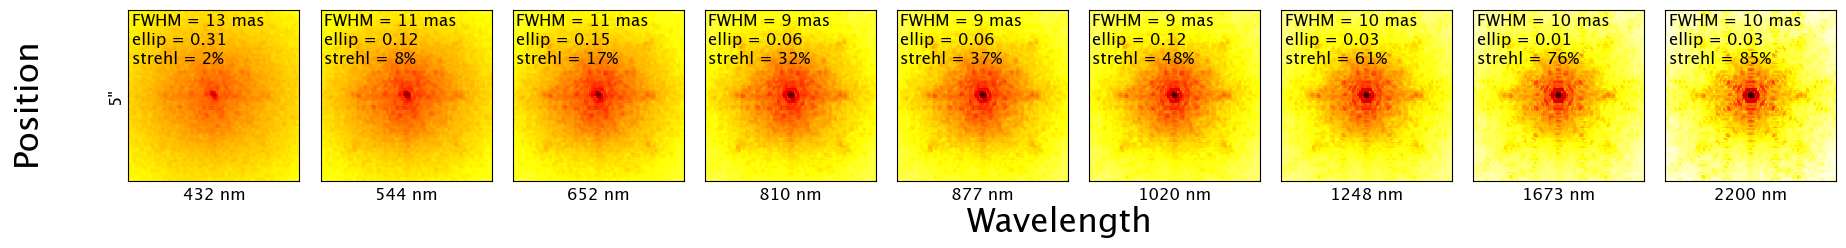

In [246]:
psf_plots.plot_psf_stack_xpos_all_wave(psf_stack_all_wvl, 5., zoom=0.2, figsize_max=20, box_scale=1.8)

In [205]:
psf_stack_all_wvl.metrics


AttributeError: 'MAOS_PSF_all_bands_stack' object has no attribute 'metrics'